# 07 Presentation-Ready Visualizations
**Project:** Retailmart Finance Analytics  
**Phase:** Build high-quality charts for reports and dashboards.

---

### 1. Setup & Imports
We must add the parent directory to the system path so Python can locate the custom `src` modules.

In [1]:
import sys
import os
import pandas as pd
import numpy as np

# Add root directory to python path
sys.path.append(os.path.abspath(os.path.join('..')))

# Import custom configurations and utilities
from src.config.config import config
from src.database.connection import db_connector
from src.utils.logger import setup_logger
from src.utils.helpers import save_dataframe

import matplotlib.pyplot as plt
import seaborn as sns

logger = setup_logger(os.path.splitext(os.path.basename('__file__'))[0])
logger.info('Notebook setup and imports loaded successfully.')

[2026-07-19 16:46:18] [INFO] [config.py:16] Loaded environment configuration from: E:\SQL ACCIO JOB\Cross functional dashboard\.env


[2026-07-19 16:46:18] [INFO] [connection.py:42] SQLAlchemy Database Engine initialized successfully.


[2026-07-19 16:46:20] [INFO] [632840764.py:19] Notebook setup and imports loaded successfully.


### 2. Define Plot Styles & Palettes
Placeholder for define plot styles & palettes steps.

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Elegant Minimalist Finance Palette (Hex Codes)
COLOR_PRIMARY = "#0F172A"    # Deep Slate/Navy
COLOR_ACCENT = "#0EA5E9"     # Elegant Teal/Sky Blue
COLOR_TEXT = "#334155"       # Muted Slate
COLOR_GRID = "#F1F5F9"       # Whisper-thin light gray

# 2. Set global theme configurations
sns.set_theme(style="white", rc={
    "axes.facecolor": "white",
    "figure.facecolor": "white",
    "grid.color": COLOR_GRID
})

# 3. Apply global Matplotlib styling parameters
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Inter", "Helvetica", "Arial"],
    "font.size": 10,
    "axes.labelsize": 11,
    "axes.labelcolor": COLOR_TEXT,
    "axes.titlesize": 13,
    "axes.titleweight": "bold",
    "axes.titlecolor": COLOR_PRIMARY,
    "xtick.labelsize": 9,
    "xtick.color": COLOR_TEXT,
    "ytick.labelsize": 9,
    "ytick.color": COLOR_TEXT,
    "legend.fontsize": 9,
    "legend.frameon": False,
    "figure.titlesize": 15,
    "grid.linestyle": "-",
    "grid.linewidth": 1,
    "axes.spines.top": False,     # Hide top border
    "axes.spines.right": False    # Hide right border
})

print("Minimalist finance styling successfully applied globally.")

Minimalist finance styling successfully applied globally.


### 3. Monthly Revenue & Profit Trends
Placeholder for monthly revenue & profit trends steps.

C:\Users\ishup\AppData\Local\Temp\ipykernel_14448\1566075747.py:55: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax1.set_xticklabels(chart_data["month_label"], rotation=45, ha="right")


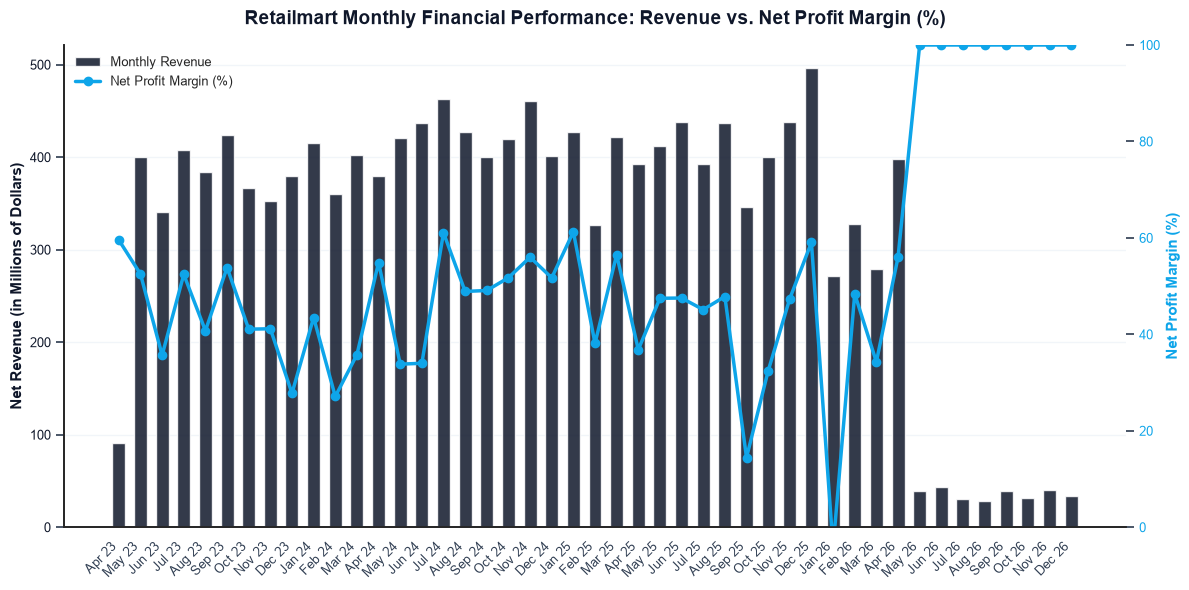

In [3]:
# --- Section 3: Executive Combo Chart ---
processed_dir = "../data/processed"
monthly_finance = pd.read_csv(os.path.join(processed_dir, "monthly_finance_summary.csv"))

# Convert months to proper date objects and sort
monthly_finance["month_date"] = pd.to_datetime(monthly_finance["month"])
monthly_finance = monthly_finance.sort_values(by="month_date")

# Exclude Q1 2023 because of the ledger data gap (zero expenses/100% margins)
chart_data = monthly_finance[monthly_finance["month"] >= "2023-04"].copy()

# Create clean date labels for the X-axis (e.g. "Apr 23")
chart_data["month_label"] = chart_data["month_date"].dt.strftime("%b %y")

# Create the figure and the primary axes (Left Y-Axis)
fig, ax1 = plt.subplots(figsize=(12, 6))

# Plot Total Revenue as vertical bars (Deep Slate/Navy)
chart_data["revenue_millions"] = chart_data["total_revenue"] / 1000000.0
bars = ax1.bar(
    chart_data["month_label"], 
    chart_data["revenue_millions"], 
    color=COLOR_PRIMARY, 
    alpha=0.85, 
    width=0.6,
    label="Monthly Revenue"
)

# Format Left Y-Axis
ax1.set_ylabel("Net Revenue (in Millions of Dollars)", color=COLOR_PRIMARY, fontweight="bold")
ax1.tick_params(axis="y", labelcolor=COLOR_PRIMARY)
ax1.grid(axis="y", linestyle="-", color=COLOR_GRID)

# Create the secondary axes (Right Y-Axis)
ax2 = ax1.twinx()

# Plot Net Profit Margin as a line chart (Sky Blue)
line = ax2.plot(
    chart_data["month_label"], 
    chart_data["net_profit_margin"], 
    color=COLOR_ACCENT, 
    linewidth=2.5, 
    marker="o", 
    markersize=6,
    label="Net Profit Margin (%)"
)

# Format Right Y-Axis
ax2.set_ylabel("Net Profit Margin (%)", color=COLOR_ACCENT, fontweight="bold")
ax2.tick_params(axis="y", labelcolor=COLOR_ACCENT)
ax2.set_ylim(0, 100)
ax2.grid(False)

# Rotate X-labels and add title
ax1.set_xticklabels(chart_data["month_label"], rotation=45, ha="right")
plt.title("Retailmart Monthly Financial Performance: Revenue vs. Net Profit Margin (%)", fontsize=14, pad=15)

# Combine legends
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines + lines2, labels + labels2, loc="upper left", frameon=False)

plt.tight_layout()
plt.show()

### 4. Regional Sales Distribution Chart
Placeholder for regional sales distribution chart steps.

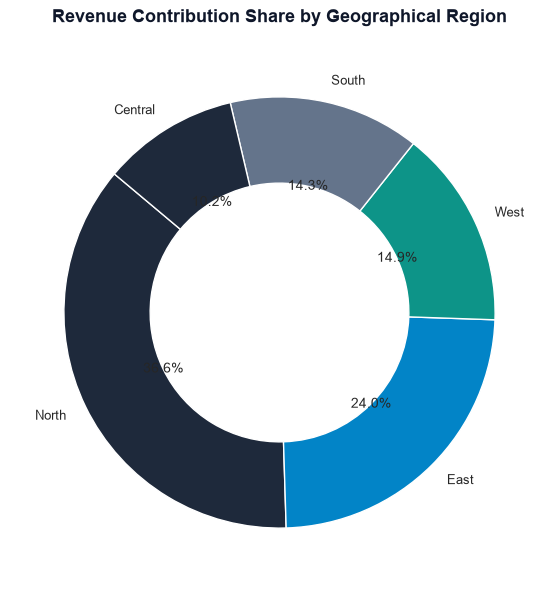

In [4]:
# --- Section 4: Regional Sales Donut Chart ---
regional_summary = pd.read_csv(os.path.join(processed_dir, "regional_sales_summary.csv"))

# Sort for consistent visualization mapping
regional_summary = regional_summary.sort_values(by="total_revenue", ascending=False)

plt.figure(figsize=(7, 7))

# Define clean, corporate pastel colors
colors = ["#1E293B", "#0284C7", "#0D9488", "#64748B"]

plt.pie(
    regional_summary["total_revenue"], 
    labels=regional_summary["region"], 
    autopct="%1.1f%%",
    startangle=140,
    colors=colors,
    wedgeprops=dict(width=0.4, edgecolor='w')
)

plt.title("Revenue Contribution Share by Geographical Region", fontsize=13, fontweight="bold", pad=15)
plt.show()

### 5. KPI Summary Visualization Card Mockups
Placeholder for kpi summary visualization card mockups steps.

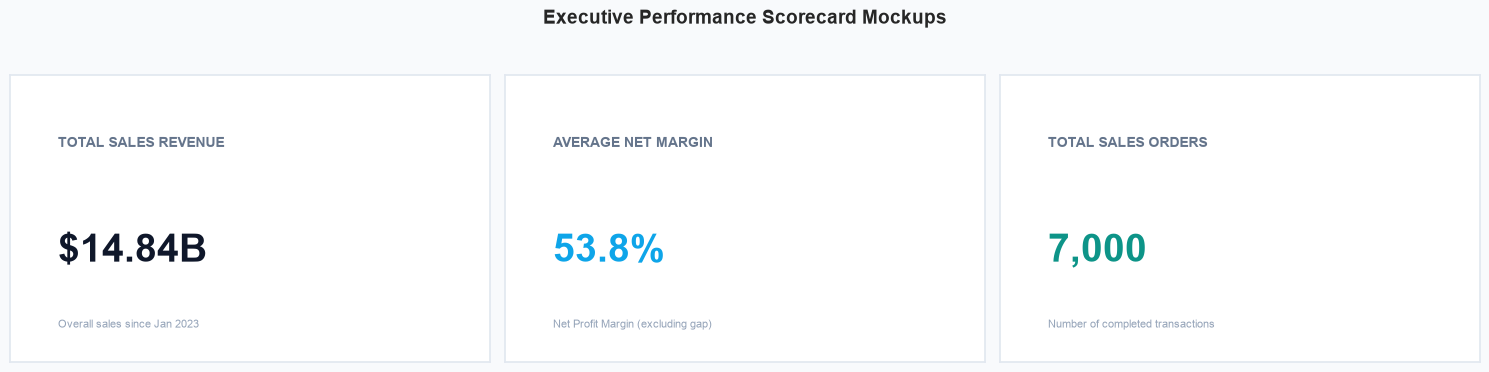

In [5]:
# --- Section 5: Highlight KPI Card Mockups ---
# We draw elegant summary blocks to mock up how they will look on our dashboard website
import os

# 1. Load orders_df to calculate total orders volume (missing variable fix)
orders_df = pd.read_csv(os.path.join(processed_dir, "sales_transaction_orders.csv"))

# 2. Calculate aggregated summary metrics
total_revenue = monthly_finance["total_revenue"].sum()
avg_margin = monthly_finance[monthly_finance["month"] >= "2023-04"]["net_profit_margin"].mean()
total_orders_volume = orders_df.shape[0]

# 3. Initialize a figure with 3 subplots side by side
fig, axes = plt.subplots(1, 3, figsize=(15, 3.5))
fig.patch.set_facecolor('#F8FAFC') # Clean background color

card_configs = [
    {"title": "TOTAL SALES REVENUE", "value": f"${total_revenue/1000000000:.2f}B", "color": "#0F172A", "desc": "Overall sales since Jan 2023"},
    {"title": "AVERAGE NET MARGIN", "value": f"{avg_margin:.1f}%", "color": "#0EA5E9", "desc": "Net Profit Margin (excluding gap)"},
    {"title": "TOTAL SALES ORDERS", "value": f"{total_orders_volume:,}", "color": "#0D9488", "desc": "Number of completed transactions"}
]

for i, cfg in enumerate(card_configs):
    ax = axes[i]
    ax.set_facecolor('#FFFFFF')
    ax.spines['top'].set_visible(True)
    ax.spines['bottom'].set_visible(True)
    ax.spines['left'].set_visible(True)
    ax.spines['right'].set_visible(True)
    ax.spines['top'].set_color('#E2E8F0')
    ax.spines['bottom'].set_color('#E2E8F0')
    ax.spines['left'].set_color('#E2E8F0')
    ax.spines['right'].set_color('#E2E8F0')
    ax.set_xticks([])
    ax.set_yticks([])
    
    # Add text labels
    ax.text(0.1, 0.75, cfg["title"], fontsize=10, color="#64748B", fontweight="bold")
    ax.text(0.1, 0.35, cfg["value"], fontsize=28, color=cfg["color"], fontweight="bold")
    ax.text(0.1, 0.12, cfg["desc"], fontsize=8, color="#94A3B8")

plt.suptitle("Executive Performance Scorecard Mockups", fontsize=14, fontweight="bold", y=1.05)
plt.tight_layout()
plt.show()